In [ ]:
import shap
import xgboost as xgb
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# load data
# I will use mushroom_reduced df, that was saved after Shap test (df has important variables only)
df = pd.read_csv("mushroom_reduced.csv")

df.head()

df.columns

Index(['class', 'does-bruise-or-bleed', 'stem-height', 'stem-width',
       'cap-surface_d', 'cap-surface_e', 'cap-surface_g', 'cap-surface_h',
       'cap-surface_i', 'cap-surface_k', 'cap-surface_l',
       'cap-surface_missing', 'cap-surface_s', 'cap-surface_t',
       'cap-surface_w', 'cap-surface_y', 'gill-attachment_a',
       'gill-attachment_d', 'gill-attachment_e', 'gill-attachment_f',
       'gill-attachment_missing', 'gill-attachment_p', 'gill-attachment_s',
       'gill-attachment_x', 'gill-spacing_c', 'gill-spacing_d',
       'gill-spacing_f', 'gill-spacing_missing', 'gill-color_b',
       'gill-color_e', 'gill-color_f', 'gill-color_g', 'gill-color_k',
       'gill-color_n', 'gill-color_o', 'gill-color_p', 'gill-color_r',
       'gill-color_u', 'gill-color_w', 'gill-color_y', 'stem-color_b',
       'stem-color_e', 'stem-color_f', 'stem-color_g', 'stem-color_k',
       'stem-color_l', 'stem-color_n', 'stem-color_o', 'stem-color_p',
       'stem-color_r', 'stem-color_u', 'st

In [2]:
# use MAD only for continuous variables, preferably the most 
# impactful one towards the target variable
variable = "stem-width"

# Calculate the median
median = df[variable].median()

# Calculate MAD
mad = np.median(np.abs(df[variable] - median))

# Define a threshold for noise detection
# adjust the numeric modifier for aggressiveness 
# e.g. try 2.5 or 4.5 etc.
# if the value is too high, you will find no noise (decrease in that case)
threshold = 2.0 * mad

# Detect noise
noise = df[np.abs(df[variable] - median) > threshold]

inliers = df.drop(noise.index)

print("Detected noise using MAD:")
noise

Detected noise using MAD:


,class,does-bruise-or-bleed,stem-height,stem-width,cap-surface_d,cap-surface_e,cap-surface_g,cap-surface_h,cap-surface_i,cap-surface_k,...,stem-color_g,stem-color_k,stem-color_l,stem-color_n,stem-color_o,stem-color_p,stem-color_r,stem-color_u,stem-color_w,stem-color_y
1071,0,1,11.81,21.48,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1088,0,1,12.01,22.12,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1110,0,1,13.13,23.58,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1140,0,1,14.17,22.11,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1142,0,1,12.82,21.49,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60686,0,0,6.37,21.57,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
60687,0,0,6.88,22.53,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
60694,0,0,5.62,23.34,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
60708,0,0,5.86,22.13,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [3]:
print(len(inliers))
print(len(noise))

52552
8517


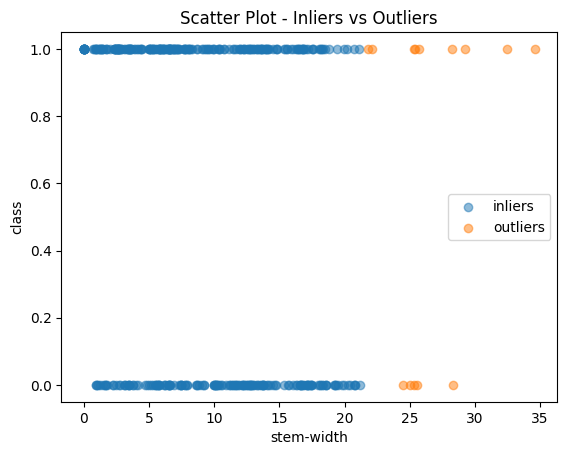

In [5]:
import matplotlib.pyplot as plt

variable = "stem-width"
target = "class"

# if you want to reduce the number of points visualized
# sample a small amount of points, for example 300-500
inliers_sample = inliers.sample(400)
outliers_sample = noise.sample(14)

plt.scatter(inliers_sample[variable], inliers_sample[target], label="inliers", alpha=0.5)
plt.scatter(outliers_sample[variable], outliers_sample[target], label="outliers", alpha=0.5)

plt.xlabel(variable)
plt.ylabel(target)

plt.title("Scatter Plot - Inliers vs Outliers")
plt.legend()
plt.show()

### Isolation forest

In [6]:
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.075) 

# fit isolation forest
y_pred = iso.fit_predict(df)

# separate outliers and inliers into separate DataFrames
outliers = df[y_pred != 1]
inliers = df[y_pred == 1]

print(f"Inliers: {len(inliers)}")
print(f"Outliers: {len(outliers)}")

Inliers: 56488
Outliers: 4581


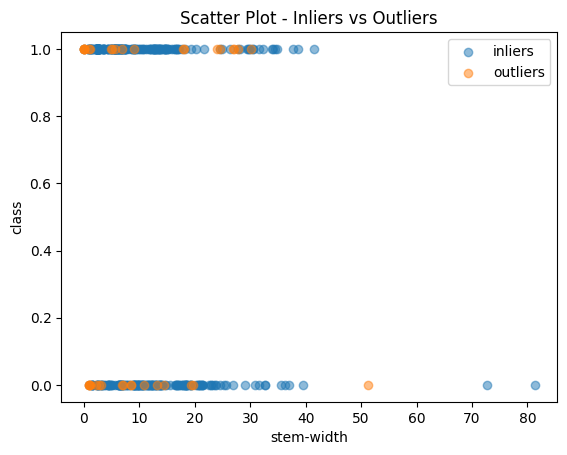

In [7]:
import matplotlib.pyplot as plt

# change the variable if you want to inspect this from other point of views
variable = "stem-width"
target = "class"

# if you want to reduce the number of points visualized
# sample a small amount of points, for example 300-500
inliers_sample = inliers.sample(400)
outliers_sample = outliers.sample(38)

plt.scatter(inliers_sample[variable], inliers_sample[target], label="inliers", alpha=0.5)
plt.scatter(outliers_sample[variable], outliers_sample[target], label="outliers", alpha=0.5)

plt.xlabel(variable)
plt.ylabel(target)

plt.title("Scatter Plot - Inliers vs Outliers")
plt.legend()
plt.show()
